In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.14.8 (tags/v3.14.8:8e6e75d, Sep 30 2026, 18:19:33) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.3
Pandas: 3.0.6


In [3]:
DATA_DIR = Path(r"C:\Users\Kinjal Chatterjee\Downloads\MILK10k")

METADATA_PATH = DATA_DIR / "metadata.csv"
GROUND_TRUTH_PATH = DATA_DIR / "supplements" / "training_gt.csv"

metadata = pd.read_csv(METADATA_PATH)
ground_truth = pd.read_csv(GROUND_TRUTH_PATH)

print("Metadata shape:", metadata.shape)
print("Ground truth shape:", ground_truth.shape)

Metadata shape: (10480, 17)
Ground truth shape: (5240, 12)


In [5]:
label_columns = [
    "AKIEC",
    "BCC",
    "BEN_OTH",
    "BKL",
    "DF",
    "INF",
    "MAL_OTH",
    "MEL",
    "NV",
    "SCCKA",
    "VASC",
]

In [6]:
class_counts = ground_truth[label_columns].sum().sort_values(ascending=False)

class_counts

BCC        2522
NV          746
BKL         544
SCCKA       473
MEL         450
AKIEC       303
DF           52
INF          50
VASC         47
BEN_OTH      44
MAL_OTH       9
dtype: int64

In [7]:
labels_per_lesion = ground_truth[label_columns].sum(axis=1)

labels_per_lesion.value_counts().sort_index()

1    5240
Name: count, dtype: int64

In [8]:
print("Ground-truth rows:", len(ground_truth))
print("Unique ground-truth lesion IDs:", ground_truth["lesion_id"].nunique())

print("Metadata rows:", len(metadata))
print("Unique metadata lesion IDs:", metadata["lesion_id"].nunique())

Ground-truth rows: 5240
Unique ground-truth lesion IDs: 5240
Metadata rows: 10480
Unique metadata lesion IDs: 5240


In [9]:
metadata_lesions = set(metadata["lesion_id"].dropna())
ground_truth_lesions = set(ground_truth["lesion_id"].dropna())

print(
    "Ground-truth lesions missing from metadata:",
    len(ground_truth_lesions - metadata_lesions)
)

print(
    "Metadata lesions missing from ground truth:",
    len(metadata_lesions - ground_truth_lesions)
)

Ground-truth lesions missing from metadata: 0
Metadata lesions missing from ground truth: 0


In [10]:
print("Metadata columns:")
print(metadata.columns.tolist())

print("\nUnique values / counts for key categorical columns:")
for col in [
    "image_type",
    "image_manipulation",
    "diagnosis_confirm_type",
    "melanocytic",
    "sex",
]:
    print(f"\n--- {col} ---")
    print(metadata[col].value_counts(dropna=False))

Metadata columns:
['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']

Unique values / counts for key categorical columns:

--- image_type ---
image_type
dermoscopic           5240
clinical: close-up    5240
Name: count, dtype: int64

--- image_manipulation ---
image_manipulation
instrument only    10145
altered              335
Name: count, dtype: int64

--- diagnosis_confirm_type ---
diagnosis_confirm_type
histopathology                            10032
single contributor clinical assessment      448
Name: count, dtype: int64

--- melanocytic ---
melanocytic
NaN     8088
True    2392
Name: count, dtype: int64

--- sex ---
sex
male      6304
female    4176
Name: count, dtype: int64


In [11]:
print("Age summary:")
print(metadata["age_approx"].describe())

print("\nAnatomical site:")
print(metadata["anatom_site_general"].value_counts(dropna=False))

print("\nImage type:")
print(metadata["image_type"].value_counts(dropna=False))

print("\nConcomitant biopsy:")
print(metadata["concomitant_biopsy"].value_counts(dropna=False))

Age summary:
count    10440.000000
mean        61.355364
std         15.691646
min          5.000000
25%         50.000000
50%         65.000000
75%         75.000000
max         85.000000
Name: age_approx, dtype: float64

Anatomical site:
anatom_site_general
NaN                3912
head/neck          2982
lower extremity    2092
upper extremity    1478
oral/genital         16
Name: count, dtype: int64

Image type:
image_type
dermoscopic           5240
clinical: close-up    5240
Name: count, dtype: int64

Concomitant biopsy:
concomitant_biopsy
True     10032
False      448
Name: count, dtype: int64


In [12]:
image_counts_per_lesion = metadata.groupby("lesion_id")["isic_id"].nunique()

print(image_counts_per_lesion.value_counts().sort_index())
print("\nLesions with exactly 2 images:",
      (image_counts_per_lesion == 2).sum())
print("Total lesions:",
      len(image_counts_per_lesion))

isic_id
2    5240
Name: count, dtype: int64

Lesions with exactly 2 images: 5240
Total lesions: 5240


In [13]:
image_type_per_lesion = (
    metadata.groupby("lesion_id")["image_type"]
    .agg(lambda x: sorted(x.dropna().unique().tolist()))
)

print(image_type_per_lesion.value_counts())

image_type
[clinical: close-up, dermoscopic]    5240
Name: count, dtype: int64


In [14]:
lesion_labels = ground_truth.copy()

lesion_labels["label"] = lesion_labels[label_columns].idxmax(axis=1)

print(lesion_labels[["lesion_id", "label"]].head())
print("\nNumber of lesion labels:")
print(lesion_labels["label"].value_counts())

    lesion_id  label
0  IL_0000652    BCC
1  IL_0003176    BCC
2  IL_0004688    BCC
3  IL_0005081  SCCKA
4  IL_0006177    BCC

Number of lesion labels:
label
BCC        2522
NV          746
BKL         544
SCCKA       473
MEL         450
AKIEC       303
DF           52
INF          50
VASC         47
BEN_OTH      44
MAL_OTH       9
Name: count, dtype: int64


In [15]:
# Create one row per lesion with image IDs separated by image type

image_table = (
    metadata[["lesion_id", "isic_id", "image_type"]]
    .pivot(index="lesion_id", columns="image_type", values="isic_id")
    .reset_index()
)

image_table = image_table.rename(columns={
    "dermoscopic": "dermoscopic_isic_id",
    "clinical: close-up": "clinical_isic_id",
})

# Add the single ground-truth class
lesion_table = lesion_labels[["lesion_id", "label"]].merge(
    image_table,
    on="lesion_id",
    how="left",
)

print("Lesion table shape:", lesion_table.shape)
print("\nColumns:")
print(lesion_table.columns.tolist())

display(lesion_table.head())

Lesion table shape: (5240, 4)

Columns:
['lesion_id', 'label', 'clinical_isic_id', 'dermoscopic_isic_id']


,lesion_id,label,clinical_isic_id,dermoscopic_isic_id
0,IL_0000652,BCC,ISIC_8149219,ISIC_4671410
1,IL_0003176,BCC,ISIC_3904045,ISIC_5371928
2,IL_0004688,BCC,ISIC_0791494,ISIC_3624913
3,IL_0005081,SCCKA,ISIC_5667730,ISIC_5186409
4,IL_0006177,BCC,ISIC_8803389,ISIC_1048297


In [16]:
metadata_consistency = metadata.groupby("lesion_id").agg(
    age_values=("age_approx", "nunique"),
    sex_values=("sex", "nunique"),
    site_values=("anatom_site_general", "nunique"),
    diagnosis_confirmation_values=("diagnosis_confirm_type", "nunique"),
)

print("Lesions with inconsistent age:", 
      (metadata_consistency["age_values"] > 1).sum())

print("Lesions with inconsistent sex:", 
      (metadata_consistency["sex_values"] > 1).sum())

print("Lesions with inconsistent anatomical site:", 
      (metadata_consistency["site_values"] > 1).sum())

print("Lesions with inconsistent confirmation type:", 
      (metadata_consistency["diagnosis_confirmation_values"] > 1).sum())

Lesions with inconsistent age: 0
Lesions with inconsistent sex: 0
Lesions with inconsistent anatomical site: 0
Lesions with inconsistent confirmation type: 0


In [17]:
from pathlib import Path

ARTIFACT_DIR = Path("../artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

lesion_table_path = ARTIFACT_DIR / "lesion_table.csv"
lesion_table.to_csv(lesion_table_path, index=False)

print(f"Saved: {lesion_table_path}")
print(f"Shape: {lesion_table.shape}")

Saved: ..\artifacts\lesion_table.csv
Shape: (5240, 4)


In [18]:
check = pd.read_csv(lesion_table_path)

print("Reloaded shape:", check.shape)
print("Unique lesions:", check["lesion_id"].nunique())
print("Duplicate lesion IDs:", check["lesion_id"].duplicated().sum())

Reloaded shape: (5240, 4)
Unique lesions: 5240
Duplicate lesion IDs: 0


In [19]:
from PIL import Image
import numpy as np

image_dir = DATA_DIR / "images"

sample_id = lesion_table.iloc[0]["dermoscopic_isic_id"]
sample_path = image_dir / f"{sample_id}.jpg"

img = Image.open(sample_path)

print("Image:", sample_id)
print("PIL mode:", img.mode)
print("PIL size:", img.size)

img_array = np.asarray(img)

print("Array shape:", img_array.shape)
print("Array dtype:", img_array.dtype)
print("Array nbytes:", img_array.nbytes)

Image: ISIC_4671410
PIL mode: RGB
PIL size: (600, 450)
Array shape: (450, 600, 3)
Array dtype: uint8
Array nbytes: 810000


In [20]:
arr = np.arange(12).reshape(3, 4)

view = arr[:, :2]
copy = arr[:, :2].copy()

print("Original:")
print(arr)

print("\nView:")
print(view)

print("\nCopy:")
print(copy)

print("\nView shares memory:", np.shares_memory(arr, view))
print("Copy shares memory:", np.shares_memory(arr, copy))

Original:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

View:
[[0 1]
 [4 5]
 [8 9]]

Copy:
[[0 1]
 [4 5]
 [8 9]]

View shares memory: True
Copy shares memory: False


In [21]:
arr_view_test = np.arange(12).reshape(3, 4)

view_test = arr_view_test[:, :2]
copy_test = arr_view_test[:, :2].copy()

view_test[0, 0] = 999
copy_test[0, 1] = 777

print("After modifying view:")
print(arr_view_test)

print("\nCopy modification does not affect original:")
print(arr_view_test)

After modifying view:
[[999   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]]

Copy modification does not affect original:
[[999   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]]


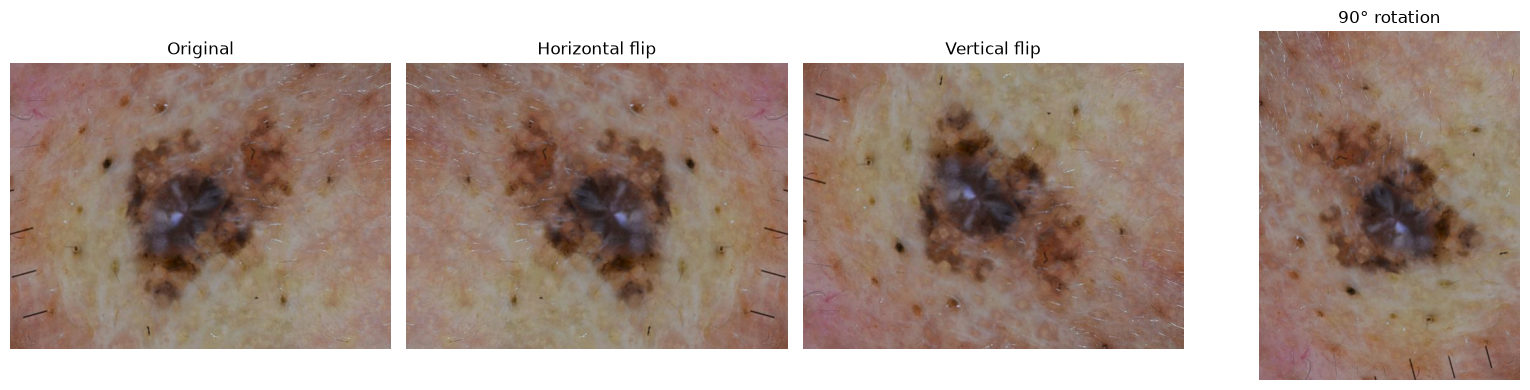

In [22]:
import matplotlib.pyplot as plt

img_rgb = np.asarray(img)

horizontal_flip = np.flip(img_rgb, axis=1)
vertical_flip = np.flip(img_rgb, axis=0)
rotated = np.rot90(img_rgb)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")

axes[1].imshow(horizontal_flip)
axes[1].set_title("Horizontal flip")

axes[2].imshow(vertical_flip)
axes[2].set_title("Vertical flip")

axes[3].imshow(rotated)
axes[3].set_title("90° rotation")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
print("Original:", img_rgb.shape)
print("Horizontal flip:", horizontal_flip.shape)
print("Vertical flip:", vertical_flip.shape)
print("90° rotation:", rotated.shape)

Original: (450, 600, 3)
Horizontal flip: (450, 600, 3)
Vertical flip: (450, 600, 3)
90° rotation: (600, 450, 3)


In [24]:
print("Original contiguous:", img_rgb.flags["C_CONTIGUOUS"])
print("Horizontal flip contiguous:", horizontal_flip.flags["C_CONTIGUOUS"])
print("Rotated contiguous:", rotated.flags["C_CONTIGUOUS"])

print("Flip shares memory:", np.shares_memory(img_rgb, horizontal_flip))
print("Rotation shares memory:", np.shares_memory(img_rgb, rotated))

Original contiguous: True
Horizontal flip contiguous: False
Rotated contiguous: False
Flip shares memory: True
Rotation shares memory: True


In [25]:
from io import BytesIO
from PIL import Image
import numpy as np

# Convert the original image to a PIL RGB image
original = Image.fromarray(img_rgb).convert("RGB")

qualities = [95, 75, 50, 25, 10]

jpeg_results = []

for quality in qualities:
    buffer = BytesIO()
    
    original.save(
        buffer,
        format="JPEG",
        quality=quality
    )
    
    compressed_bytes = buffer.getvalue()
    
    # Reload the compressed JPEG
    compressed = Image.open(BytesIO(compressed_bytes)).convert("RGB")
    compressed_array = np.asarray(compressed).astype(np.float64)
    
    original_array = np.asarray(original).astype(np.float64)
    
    # Mean squared error
    mse = np.mean((original_array - compressed_array) ** 2)
    
    # PSNR
    if mse == 0:
        psnr = float("inf")
    else:
        psnr = 10 * np.log10((255 ** 2) / mse)
    
    jpeg_results.append({
        "quality": quality,
        "file_size_bytes": len(compressed_bytes),
        "mse": mse,
        "psnr_db": psnr,
    })

jpeg_results

[{'quality': 95,
  'file_size_bytes': 56939,
  'mse': np.float64(0.4191382716049383),
  'psnr_db': np.float64(51.907230427017474)},
 {'quality': 75,
  'file_size_bytes': 29772,
  'mse': np.float64(0.008574074074074074),
  'psnr_db': np.float64(68.79893129672925)},
 {'quality': 50,
  'file_size_bytes': 23287,
  'mse': np.float64(12.325304938271605),
  'psnr_db': np.float64(37.22282687979867)},
 {'quality': 25,
  'file_size_bytes': 12020,
  'mse': np.float64(22.409358024691358),
  'psnr_db': np.float64(34.62650945668307)},
 {'quality': 10,
  'file_size_bytes': 6700,
  'mse': np.float64(52.614758024691355),
  'psnr_db': np.float64(30.919727834495305)}]

In [26]:
jpeg_results_df = pd.DataFrame(jpeg_results)
jpeg_results_df

,quality,file_size_bytes,mse,psnr_db
0,95,56939,0.419138,51.907230
1,75,29772,0.008574,68.798931
2,50,23287,12.325305,37.222827
3,25,12020,22.409358,34.626509
4,10,6700,52.614758,30.919728


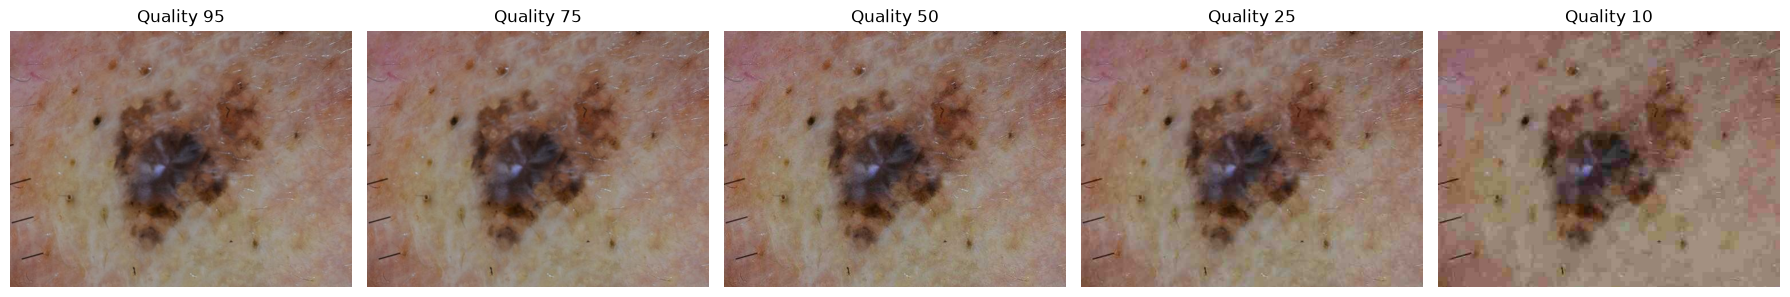

In [27]:
fig, axes = plt.subplots(1, len(qualities), figsize=(18, 4))

for ax, quality in zip(axes, qualities):
    buffer = BytesIO()
    original.save(buffer, format="JPEG", quality=quality)
    
    compressed = Image.open(BytesIO(buffer.getvalue())).convert("RGB")
    
    ax.imshow(compressed)
    ax.set_title(f"Quality {quality}")
    ax.axis("off")

plt.tight_layout()
plt.show()

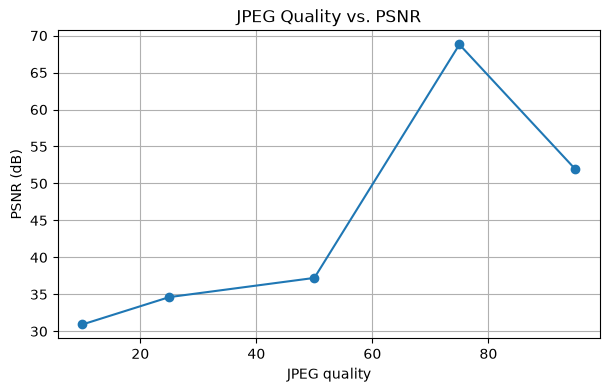

In [28]:
plt.figure(figsize=(7, 4))

plt.plot(
    jpeg_results_df["quality"],
    jpeg_results_df["psnr_db"],
    marker="o"
)

plt.xlabel("JPEG quality")
plt.ylabel("PSNR (dB)")
plt.title("JPEG Quality vs. PSNR")
plt.grid(True)
plt.show()

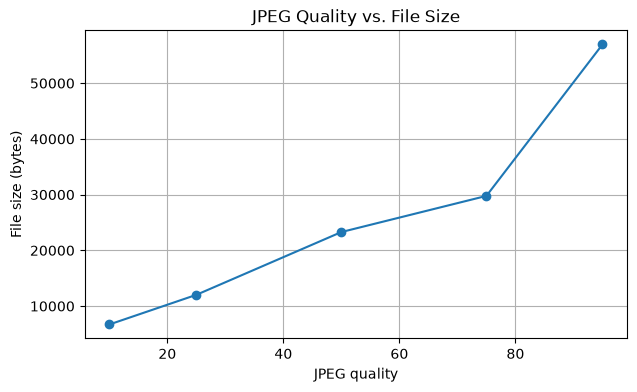

In [30]:
plt.figure(figsize=(7, 4))

plt.plot(
    jpeg_results_df["quality"],
    jpeg_results_df["file_size_bytes"],
    marker="o"
)

plt.xlabel("JPEG quality")
plt.ylabel("File size (bytes)")
plt.title("JPEG Quality vs. File Size")
plt.grid(True)
plt.show()

In [31]:
import os

metadata_with_size = metadata.copy()

metadata_with_size["file_size_bytes"] = metadata_with_size["isic_id"].apply(
    lambda x: (image_dir / f"{x}.jpg").stat().st_size
)

print(metadata_with_size["file_size_bytes"].describe())

count     10480.000000
mean      33839.778531
std       10505.902963
min       11822.000000
25%       25729.500000
50%       32172.500000
75%       40691.000000
max      101478.000000
Name: file_size_bytes, dtype: float64


In [32]:
metadata_with_size = metadata_with_size.merge(
    lesion_labels[["lesion_id", "label"]],
    on="lesion_id",
    how="left"
)

print(metadata_with_size[["isic_id", "lesion_id", "label", "file_size_bytes"]].head())

        isic_id   lesion_id  label  file_size_bytes
0  ISIC_0051817  IL_1612768  SCCKA            42546
1  ISIC_0073863  IL_2547802     NV            26084
2  ISIC_0075884  IL_9270970     NV            39282
3  ISIC_0076255  IL_8089688    BCC            23797
4  ISIC_0077054  IL_5271098    BCC            26610


In [33]:
file_size_by_class = (
    metadata_with_size
    .groupby("label")["file_size_bytes"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

file_size_by_class

,count,mean,median,std,min,max
label,,,,,,
MEL,900,37125.712222,34507.0,12475.822442,15530,101478
AKIEC,606,35520.265677,33903.0,9809.694877,15113,75365
MAL_OTH,18,35184.388889,36991.0,9519.659399,17976,50441
SCCKA,946,34528.507400,33463.0,9081.176199,15481,60257
BKL,1088,34276.260110,33086.5,10115.239164,14804,90049
NV,1492,33948.723861,31545.5,11289.844303,11822,84988
INF,100,33871.170000,31607.0,12042.808497,15200,73050
BCC,5044,32905.989096,31384.0,10080.047622,12452,100117
VASC,94,32169.563830,30190.0,12007.832223,14579,73580


In [34]:
from sklearn.metrics import roc_auc_score

auc_results = []

for label in sorted(metadata_with_size["label"].unique()):
    y_true = (metadata_with_size["label"] == label).astype(int)
    
    # File size itself as a score
    auc = roc_auc_score(
        y_true,
        metadata_with_size["file_size_bytes"]
    )
    
    # Also test the opposite direction
    auc_inverse = roc_auc_score(
        y_true,
        -metadata_with_size["file_size_bytes"]
    )
    
    auc_results.append({
        "label": label,
        "auc_size": auc,
        "auc_inverse_size": auc_inverse,
        "best_auc": max(auc, auc_inverse),
    })

auc_results_df = pd.DataFrame(auc_results).sort_values(
    "best_auc",
    ascending=False
)

auc_results_df

,label,auc_size,auc_inverse_size,best_auc
2,BEN_OTH,0.406310,0.593690,0.593690
7,MEL,0.580060,0.419940,0.580060
6,MAL_OTH,0.558789,0.441211,0.558789
10,VASC,0.441520,0.558480,0.558480
0,AKIEC,0.558192,0.441808,0.558192
1,BCC,0.453814,0.546186,0.546186
4,DF,0.454071,0.545929,0.545929
9,SCCKA,0.534276,0.465724,0.534276
3,BKL,0.518048,0.481952,0.518048
5,INF,0.485277,0.514723,0.514723


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# One row per image, with its lesion-level label
image_level = metadata[["isic_id", "lesion_id", "image_type"]].merge(
    lesion_labels[["lesion_id", "label"]],
    on="lesion_id",
    how="left"
)

print("Image-level table shape:", image_level.shape)
print("Unique images:", image_level["isic_id"].nunique())
print("Unique lesions:", image_level["lesion_id"].nunique())

image_level.head()

Image-level table shape: (10480, 4)
Unique images: 10480
Unique lesions: 5240


,isic_id,lesion_id,image_type,label
0,ISIC_0051817,IL_1612768,dermoscopic,SCCKA
1,ISIC_0073863,IL_2547802,dermoscopic,NV
2,ISIC_0075884,IL_9270970,clinical: close-up,NV
3,ISIC_0076255,IL_8089688,dermoscopic,BCC
4,ISIC_0077054,IL_5271098,dermoscopic,BCC


In [36]:
train_img, test_img = train_test_split(
    image_level,
    test_size=0.20,
    random_state=42,
    stratify=image_level["label"]
)

print("Image-level train:", train_img.shape)
print("Image-level test:", test_img.shape)

train_lesions = set(train_img["lesion_id"])
test_lesions = set(test_img["lesion_id"])

overlap = train_lesions & test_lesions

print("Train lesions:", len(train_lesions))
print("Test lesions:", len(test_lesions))
print("Lesions appearing in BOTH:", len(overlap))

Image-level train: (8384, 4)
Image-level test: (2096, 4)
Train lesions: 5051
Test lesions: 1907
Lesions appearing in BOTH: 1718


In [37]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        image_level,
        y=image_level["label"],
        groups=image_level["lesion_id"]
    )
)

train_group = image_level.iloc[train_idx].copy()
test_group = image_level.iloc[test_idx].copy()

print("Lesion-level train:", train_group.shape)
print("Lesion-level test:", test_group.shape)

train_lesions_group = set(train_group["lesion_id"])
test_lesions_group = set(test_group["lesion_id"])

overlap_group = train_lesions_group & test_lesions_group

print("Train lesions:", len(train_lesions_group))
print("Test lesions:", len(test_lesions_group))
print("Lesions appearing in BOTH:", len(overlap_group))

Lesion-level train: (8384, 4)
Lesion-level test: (2096, 4)
Train lesions: 4192
Test lesions: 1048
Lesions appearing in BOTH: 0


In [39]:
from sklearn.metrics import accuracy_score

# Map each training lesion to its known label
train_label_by_lesion = (
    train_img
    .drop_duplicates("lesion_id")
    .set_index("lesion_id")["label"]
)

test_img_with_oracle = test_img.copy()

# If the sibling lesion is present in training, retrieve its label
test_img_with_oracle["oracle_prediction"] = (
    test_img_with_oracle["lesion_id"]
    .map(train_label_by_lesion)
)

# Only evaluate rows where the sibling is available
oracle_mask = test_img_with_oracle["oracle_prediction"].notna()

oracle_coverage = oracle_mask.mean()

oracle_accuracy = accuracy_score(
    test_img_with_oracle.loc[oracle_mask, "label"],
    test_img_with_oracle.loc[oracle_mask, "oracle_prediction"]
)

print(f"Sibling oracle coverage: {oracle_coverage:.3f}")
print(f"Sibling oracle accuracy: {oracle_accuracy:.3f}")

Sibling oracle coverage: 0.820
Sibling oracle accuracy: 1.000


In [40]:
train_label_by_lesion_group = (
    train_group
    .drop_duplicates("lesion_id")
    .set_index("lesion_id")["label"]
)

test_group_with_oracle = test_group.copy()

test_group_with_oracle["oracle_prediction"] = (
    test_group_with_oracle["lesion_id"]
    .map(train_label_by_lesion_group)
)

oracle_coverage_group = (
    test_group_with_oracle["oracle_prediction"].notna().mean()
)

print(f"Lesion-level oracle coverage: {oracle_coverage_group:.3f}")

Lesion-level oracle coverage: 0.000


In [41]:
print("IMAGE-LEVEL SPLIT")
print("Train images:", len(train_img))
print("Test images:", len(test_img))
print("Train lesions:", train_img["lesion_id"].nunique())
print("Test lesions:", test_img["lesion_id"].nunique())
print("Overlapping lesions:", len(
    set(train_img["lesion_id"]) & set(test_img["lesion_id"])
))

print("\nLESION-LEVEL SPLIT")
print("Train images:", len(train_group))
print("Test images:", len(test_group))
print("Train lesions:", train_group["lesion_id"].nunique())
print("Test lesions:", test_group["lesion_id"].nunique())
print("Overlapping lesions:", len(
    set(train_group["lesion_id"]) & set(test_group["lesion_id"])
))

IMAGE-LEVEL SPLIT
Train images: 8384
Test images: 2096
Train lesions: 5051
Test lesions: 1907
Overlapping lesions: 1718

LESION-LEVEL SPLIT
Train images: 8384
Test images: 2096
Train lesions: 4192
Test lesions: 1048
Overlapping lesions: 0


In [42]:
from sklearn.model_selection import train_test_split


def make_lesion_split(
    df,
    lesion_col="lesion_id",
    label_col="label",
    test_size=0.20,
    val_size=0.20,
    random_state=42,
):
    """
    Split a lesion-level table into train, validation, and test sets.

    Each lesion_id is assigned to exactly one partition.
    Stratification is performed using the lesion-level label.
    """

    # One row per lesion is required
    lesion_df = df[[lesion_col, label_col]].drop_duplicates()

    # Safety check: every lesion must have exactly one label
    label_counts = lesion_df.groupby(lesion_col)[label_col].nunique()

    if not (label_counts == 1).all():
        raise ValueError(
            "Each lesion must have exactly one unique label."
        )

    # First split: train vs temporary (validation + test)
    train_lesions, temp_lesions = train_test_split(
        lesion_df,
        test_size=test_size + val_size,
        random_state=random_state,
        stratify=lesion_df[label_col],
    )

    # Convert desired validation fraction into a fraction of temp
    val_fraction_of_temp = val_size / (test_size + val_size)

    # Second split: validation vs test
    val_lesions, test_lesions = train_test_split(
        temp_lesions,
        test_size=1 - val_fraction_of_temp,
        random_state=random_state,
        stratify=temp_lesions[label_col],
    )

    train_ids = set(train_lesions[lesion_col])
    val_ids = set(val_lesions[lesion_col])
    test_ids = set(test_lesions[lesion_col])

    # Map the lesion IDs back to the original image-level table
    train = df[df[lesion_col].isin(train_ids)].copy()
    val = df[df[lesion_col].isin(val_ids)].copy()
    test = df[df[lesion_col].isin(test_ids)].copy()

    return train, val, test

In [43]:
train_split, val_split, test_split = make_lesion_split(
    image_level,
    test_size=0.20,
    val_size=0.20,
    random_state=42,
)

print("Train:", train_split.shape)
print("Validation:", val_split.shape)
print("Test:", test_split.shape)

print("\nUnique lesions:")
print("Train:", train_split["lesion_id"].nunique())
print("Validation:", val_split["lesion_id"].nunique())
print("Test:", test_split["lesion_id"].nunique())

Train: (6288, 4)
Validation: (2096, 4)
Test: (2096, 4)

Unique lesions:
Train: 3144
Validation: 1048
Test: 1048


In [44]:
train_ids = set(train_split["lesion_id"])
val_ids = set(val_split["lesion_id"])
test_ids = set(test_split["lesion_id"])

print("Train ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("\n✓ No lesion appears in more than one split.")

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ No lesion appears in more than one split.


In [45]:
original_ids = set(image_level["isic_id"])

train_image_ids = set(train_split["isic_id"])
val_image_ids = set(val_split["isic_id"])
test_image_ids = set(test_split["isic_id"])

# No image overlap
assert train_image_ids.isdisjoint(val_image_ids)
assert train_image_ids.isdisjoint(test_image_ids)
assert val_image_ids.isdisjoint(test_image_ids)

# No images lost
combined_ids = train_image_ids | val_image_ids | test_image_ids

assert combined_ids == original_ids

print("✓ No image appears in multiple splits.")
print("✓ No images were lost.")
print("✓ All original images are assigned to exactly one split.")

✓ No image appears in multiple splits.
✓ No images were lost.
✓ All original images are assigned to exactly one split.


In [46]:
for split_name, split_df in {
    "train": train_split,
    "validation": val_split,
    "test": test_split,
}.items():

    images_per_lesion = split_df.groupby("lesion_id")["isic_id"].nunique()

    assert (images_per_lesion == 2).all(), (
        f"{split_name} contains a lesion without exactly two images."
    )

print("✓ Every lesion has both images in its assigned split.")

✓ Every lesion has both images in its assigned split.


In [47]:
for split_name, split_df in {
    "train": train_split,
    "validation": val_split,
    "test": test_split,
}.items():

    labels_per_lesion = (
        split_df.groupby("lesion_id")["label"]
        .nunique()
    )

    assert (labels_per_lesion == 1).all(), (
        f"{split_name} contains a lesion with inconsistent labels."
    )

print("✓ Every lesion has exactly one label.")

✓ Every lesion has exactly one label.


In [48]:
from sklearn.model_selection import (
    StratifiedKFold,
    GroupKFold,
    StratifiedGroupKFold,
)

In [49]:
def evaluate_cv_splitter(splitter, X, y, groups=None, name="splitter"):
    results = []

    for fold, (train_idx, val_idx) in enumerate(
        splitter.split(X, y, groups=groups),
        start=1
    ):
        train_df = X.iloc[train_idx]
        val_df = X.iloc[val_idx]

        train_lesions = set(train_df["lesion_id"])
        val_lesions = set(val_df["lesion_id"])

        overlap = len(train_lesions & val_lesions)

        train_props = train_df["label"].value_counts(
            normalize=True
        )

        val_props = val_df["label"].value_counts(
            normalize=True
        )

        # Maximum absolute difference in class proportions
        common_labels = train_props.index.union(val_props.index)

        max_class_difference = max(
            abs(
                train_props.reindex(common_labels, fill_value=0)
                - val_props.reindex(common_labels, fill_value=0)
            )
        )

        results.append({
            "splitter": name,
            "fold": fold,
            "train_images": len(train_df),
            "val_images": len(val_df),
            "train_lesions": train_df["lesion_id"].nunique(),
            "val_lesions": val_df["lesion_id"].nunique(),
            "lesion_overlap": overlap,
            "max_class_proportion_difference": max_class_difference,
        })

    return pd.DataFrame(results)

In [50]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

skf_results = evaluate_cv_splitter(
    skf,
    image_level,
    image_level["label"],
    name="StratifiedKFold",
)

skf_results

,splitter,fold,train_images,val_images,train_lesions,val_lesions,lesion_overlap,max_class_proportion_difference
0,StratifiedKFold,1,8384,2096,5041,1897,1698,0.000477
1,StratifiedKFold,2,8384,2096,5011,1867,1638,0.000358
2,StratifiedKFold,3,8384,2096,5020,1876,1656,0.000477
3,StratifiedKFold,4,8384,2096,5026,1882,1668,0.000358
4,StratifiedKFold,5,8384,2096,5020,1876,1656,0.000477


In [51]:
gkf = GroupKFold(
    n_splits=5
)

gkf_results = evaluate_cv_splitter(
    gkf,
    image_level,
    image_level["label"],
    groups=image_level["lesion_id"],
    name="GroupKFold",
)

gkf_results

,splitter,fold,train_images,val_images,train_lesions,val_lesions,lesion_overlap,max_class_proportion_difference
0,GroupKFold,1,8384,2096,4192,1048,0,0.020038
1,GroupKFold,2,8384,2096,4192,1048,0,0.015983
2,GroupKFold,3,8384,2096,4192,1048,0,0.022185
3,GroupKFold,4,8384,2096,4192,1048,0,0.025286
4,GroupKFold,5,8384,2096,4192,1048,0,0.021469


In [52]:
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

sgkf_results = evaluate_cv_splitter(
    sgkf,
    image_level,
    image_level["label"],
    groups=image_level["lesion_id"],
    name="StratifiedGroupKFold",
)

sgkf_results

,splitter,fold,train_images,val_images,train_lesions,val_lesions,lesion_overlap,max_class_proportion_difference
0,StratifiedGroupKFold,1,8384,2096,4192,1048,0,0.000954
1,StratifiedGroupKFold,2,8384,2096,4192,1048,0,0.000954
2,StratifiedGroupKFold,3,8384,2096,4192,1048,0,0.000477
3,StratifiedGroupKFold,4,8384,2096,4192,1048,0,0.000716
4,StratifiedGroupKFold,5,8384,2096,4192,1048,0,0.000954


In [53]:
cv_results = pd.concat(
    [
        skf_results,
        gkf_results,
        sgkf_results,
    ],
    ignore_index=True,
)

cv_results

,splitter,fold,train_images,val_images,train_lesions,val_lesions,lesion_overlap,max_class_proportion_difference
0,StratifiedKFold,1,8384,2096,5041,1897,1698,0.000477
1,StratifiedKFold,2,8384,2096,5011,1867,1638,0.000358
2,StratifiedKFold,3,8384,2096,5020,1876,1656,0.000477
3,StratifiedKFold,4,8384,2096,5026,1882,1668,0.000358
4,StratifiedKFold,5,8384,2096,5020,1876,1656,0.000477
5,GroupKFold,1,8384,2096,4192,1048,0,0.020038
6,GroupKFold,2,8384,2096,4192,1048,0,0.015983
7,GroupKFold,3,8384,2096,4192,1048,0,0.022185
8,GroupKFold,4,8384,2096,4192,1048,0,0.025286
9,GroupKFold,5,8384,2096,4192,1048,0,0.021469


In [54]:
cv_summary = (
    cv_results
    .groupby("splitter")
    .agg(
        mean_lesion_overlap=("lesion_overlap", "mean"),
        max_lesion_overlap=("lesion_overlap", "max"),
        mean_class_difference=(
            "max_class_proportion_difference",
            "mean"
        ),
        max_class_difference=(
            "max_class_proportion_difference",
            "max"
        ),
    )
    .reset_index()
)

cv_summary

,splitter,mean_lesion_overlap,max_lesion_overlap,mean_class_difference,max_class_difference
0,GroupKFold,0.0,0,0.020992,0.025286
1,StratifiedGroupKFold,0.0,0,0.000811,0.000954
2,StratifiedKFold,1663.2,1698,0.000429,0.000477


In [55]:
for fold, (_, val_idx) in enumerate(
    sgkf.split(
        image_level,
        image_level["label"],
        groups=image_level["lesion_id"],
    ),
    start=1
):
    val_df = image_level.iloc[val_idx]

    print(
        f"Fold {fold}:",
        val_df["label"].value_counts().sort_index().to_dict()
    )

Fold 1: {'AKIEC': 120, 'BCC': 1008, 'BEN_OTH': 18, 'BKL': 218, 'DF': 22, 'INF': 20, 'MAL_OTH': 2, 'MEL': 180, 'NV': 300, 'SCCKA': 190, 'VASC': 18}
Fold 2: {'AKIEC': 122, 'BCC': 1010, 'BEN_OTH': 16, 'BKL': 218, 'DF': 20, 'INF': 20, 'MAL_OTH': 4, 'MEL': 180, 'NV': 298, 'SCCKA': 190, 'VASC': 18}
Fold 3: {'AKIEC': 122, 'BCC': 1008, 'BEN_OTH': 18, 'BKL': 218, 'DF': 20, 'INF': 20, 'MAL_OTH': 4, 'MEL': 180, 'NV': 298, 'SCCKA': 190, 'VASC': 18}
Fold 4: {'AKIEC': 120, 'BCC': 1008, 'BEN_OTH': 18, 'BKL': 218, 'DF': 22, 'INF': 20, 'MAL_OTH': 4, 'MEL': 180, 'NV': 298, 'SCCKA': 188, 'VASC': 20}
Fold 5: {'AKIEC': 122, 'BCC': 1010, 'BEN_OTH': 18, 'BKL': 216, 'DF': 20, 'INF': 20, 'MAL_OTH': 4, 'MEL': 180, 'NV': 298, 'SCCKA': 188, 'VASC': 20}


In [56]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

X_train = train_split[["isic_id"]]
y_train = train_split["label"]

X_test = test_split[["isic_id"]]
y_test = test_split["label"]

print("Training images:", len(X_train))
print("Test images:", len(X_test))
print("Number of classes:", y_train.nunique())

Training images: 6288
Test images: 2096
Number of classes: 11


In [57]:
majority_dummy = DummyClassifier(
    strategy="most_frequent"
)

majority_dummy.fit(X_train, y_train)

y_pred_majority = majority_dummy.predict(X_test)

majority_accuracy = accuracy_score(
    y_test,
    y_pred_majority
)

majority_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_majority
)

majority_macro_f1 = f1_score(
    y_test,
    y_pred_majority,
    average="macro",
    zero_division=0
)

print(f"Majority accuracy: {majority_accuracy:.4f}")
print(f"Majority balanced accuracy: {majority_balanced_accuracy:.4f}")
print(f"Majority macro F1: {majority_macro_f1:.4f}")

Majority accuracy: 0.4809
Majority balanced accuracy: 0.0909
Majority macro F1: 0.0590


In [58]:
stratified_dummy = DummyClassifier(
    strategy="stratified",
    random_state=42
)

stratified_dummy.fit(X_train, y_train)

y_pred_stratified = stratified_dummy.predict(X_test)

stratified_accuracy = accuracy_score(
    y_test,
    y_pred_stratified
)

stratified_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_stratified
)

stratified_macro_f1 = f1_score(
    y_test,
    y_pred_stratified,
    average="macro",
    zero_division=0
)

print(f"Stratified accuracy: {stratified_accuracy:.4f}")
print(
    f"Stratified balanced accuracy: "
    f"{stratified_balanced_accuracy:.4f}"
)
print(f"Stratified macro F1: {stratified_macro_f1:.4f}")

Stratified accuracy: 0.2791
Stratified balanced accuracy: 0.0890
Stratified macro F1: 0.0887


In [59]:
baseline_results = pd.DataFrame([
    {
        "model": "Majority",
        "accuracy": majority_accuracy,
        "balanced_accuracy": majority_balanced_accuracy,
        "macro_f1": majority_macro_f1,
    },
    {
        "model": "Stratified",
        "accuracy": stratified_accuracy,
        "balanced_accuracy": stratified_balanced_accuracy,
        "macro_f1": stratified_macro_f1,
    },
])

baseline_results

,model,accuracy,balanced_accuracy,macro_f1
0,Majority,0.480916,0.090909,0.059044
1,Stratified,0.279103,0.089049,0.088666


In [60]:
labels = sorted(y_test.unique())

cm_majority = confusion_matrix(
    y_test,
    y_pred_majority,
    labels=labels
)

cm_majority_df = pd.DataFrame(
    cm_majority,
    index=labels,
    columns=labels
)

cm_majority_df

,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
AKIEC,0,120,0,0,0,0,0,0,0,0,0
BCC,0,1008,0,0,0,0,0,0,0,0,0
BEN_OTH,0,18,0,0,0,0,0,0,0,0,0
BKL,0,218,0,0,0,0,0,0,0,0,0
DF,0,22,0,0,0,0,0,0,0,0,0
INF,0,20,0,0,0,0,0,0,0,0,0
MAL_OTH,0,4,0,0,0,0,0,0,0,0,0
MEL,0,180,0,0,0,0,0,0,0,0,0
NV,0,298,0,0,0,0,0,0,0,0,0
SCCKA,0,190,0,0,0,0,0,0,0,0,0


In [61]:
print(
    classification_report(
        y_test,
        y_pred_majority,
        labels=labels,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       AKIEC       0.00      0.00      0.00       120
         BCC       0.48      1.00      0.65      1008
     BEN_OTH       0.00      0.00      0.00        18
         BKL       0.00      0.00      0.00       218
          DF       0.00      0.00      0.00        22
         INF       0.00      0.00      0.00        20
     MAL_OTH       0.00      0.00      0.00         4
         MEL       0.00      0.00      0.00       180
          NV       0.00      0.00      0.00       298
       SCCKA       0.00      0.00      0.00       190
        VASC       0.00      0.00      0.00        18

    accuracy                           0.48      2096
   macro avg       0.04      0.09      0.06      2096
weighted avg       0.23      0.48      0.31      2096



In [63]:
label_order = sorted(lesion_labels["label"].unique())

cost_matrix = pd.DataFrame(
    np.ones(
        (len(label_order), len(label_order)),
        dtype=float
).copy(),
    index=label_order,
    columns=label_order,
)

for label in label_order:
    cost_matrix.loc[label, label] = 0

cost_matrix

,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
AKIEC,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BCC,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BEN_OTH,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BKL,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
DF,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
INF,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
MAL_OTH,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
MEL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
NV,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
SCCKA,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0


In [64]:
def calculate_cost(y_true, y_pred, cost_matrix):
    total_cost = 0

    for true_label, predicted_label in zip(y_true, y_pred):
        total_cost += cost_matrix.loc[
            true_label,
            predicted_label
        ]

    return total_cost


majority_total_cost = calculate_cost(
    y_test,
    y_pred_majority,
    cost_matrix
)

majority_mean_cost = (
    majority_total_cost / len(y_test)
)

print(f"Majority total cost: {majority_total_cost:.0f}")
print(f"Majority mean cost: {majority_mean_cost:.4f}")

Majority total cost: 1088
Majority mean cost: 0.5191


In [65]:
baseline_results

,model,accuracy,balanced_accuracy,macro_f1
0,Majority,0.480916,0.090909,0.059044
1,Stratified,0.279103,0.089049,0.088666


In [66]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import numpy as np

sample_id = lesion_table.iloc[0]["dermoscopic_isic_id"]
sample_path = image_dir / f"{sample_id}.jpg"

sample_image = Image.open(sample_path).convert("RGB")

print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

Image size: (600, 450)
Image mode: RGB


In [67]:
def adjust_hue(image, hue_shift):
    """
    Shift hue by hue_shift in [-1, 1].
    """
    hsv = np.asarray(image.convert("HSV")).copy()

    # PIL stores hue in [0, 255]
    shift = int(hue_shift * 255)

    hsv[..., 0] = (
        hsv[..., 0].astype(np.int16) + shift
    ) % 256

    return Image.fromarray(hsv.astype(np.uint8), mode="HSV").convert("RGB")


brightness_factors = [0.7, 1.0, 1.3]
hue_shifts = [-0.05, 0.0, 0.05]

brightness_images = [
    ImageEnhance.Brightness(sample_image).enhance(f)
    for f in brightness_factors
]

hue_images = [
    adjust_hue(sample_image, h)
    for h in hue_shifts
]

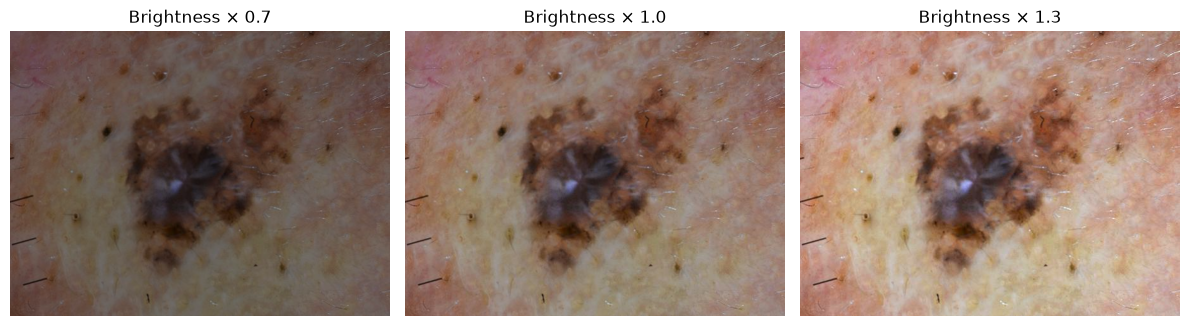

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, image, factor in zip(
    axes,
    brightness_images,
    brightness_factors
):
    ax.imshow(image)
    ax.set_title(f"Brightness × {factor}")
    ax.axis("off")

plt.tight_layout()
plt.show()

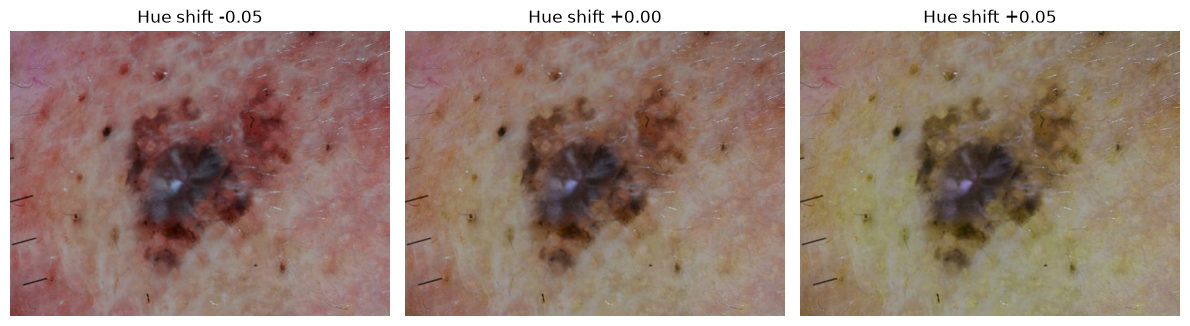

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, image, shift in zip(
    axes,
    hue_images,
    hue_shifts
):
    ax.imshow(image)
    ax.set_title(f"Hue shift {shift:+.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [70]:
original_array = np.asarray(sample_image).astype(np.float32)


def mean_absolute_difference(image_a, image_b):
    a = np.asarray(image_a).astype(np.float32)
    b = np.asarray(image_b).astype(np.float32)

    return np.mean(np.abs(a - b))


brightness_differences = [
    mean_absolute_difference(sample_image, image)
    for image in brightness_images
]

hue_differences = [
    mean_absolute_difference(sample_image, image)
    for image in hue_images
]

augmentation_audit = pd.DataFrame({
    "augmentation": (
        [f"brightness_{f}" for f in brightness_factors]
        + [f"hue_{h:+.2f}" for h in hue_shifts]
    ),
    "mean_absolute_pixel_difference": (
        brightness_differences + hue_differences
    ),
})

augmentation_audit

,augmentation,mean_absolute_pixel_difference
0,brightness_0.7,35.593105
1,brightness_1.0,0.000000
2,brightness_1.3,34.686623
3,hue_-0.05,3.931232
4,hue_+0.00,0.141316
5,hue_+0.05,3.759164


In [71]:
strong_brightness = [
    ImageEnhance.Brightness(sample_image).enhance(f)
    for f in [0.4, 1.6]
]

strong_hue = [
    adjust_hue(sample_image, h)
    for h in [-0.20, 0.20]
]

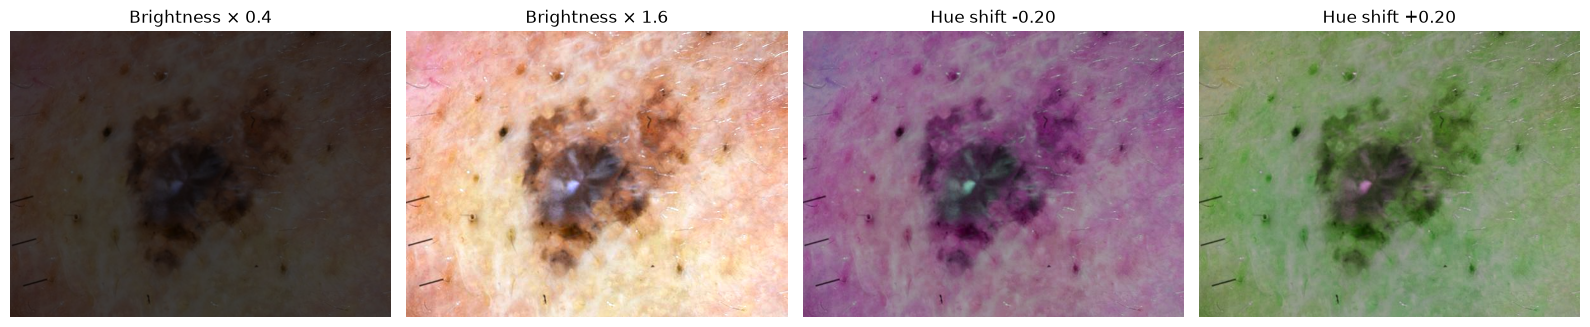

In [72]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

images = strong_brightness + strong_hue
titles = [
    "Brightness × 0.4",
    "Brightness × 1.6",
    "Hue shift -0.20",
    "Hue shift +0.20",
]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [73]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd

In [74]:
class LesionDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, label_to_idx=None):
        self.df = df.reset_index(drop=True).copy()
        self.image_dir = image_dir
        self.transform = transform

        if label_to_idx is None:
            labels = sorted(self.df["label"].unique())
            self.label_to_idx = {
                label: idx for idx, label in enumerate(labels)
            }
        else:
            self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self.image_dir / f"{row['isic_id']}.jpg"
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = self.label_to_idx[row["label"]]

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "lesion_id": row["lesion_id"],
            "isic_id": row["isic_id"],
        }

In [75]:
dataset_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [76]:
label_to_idx = {
    label: idx
    for idx, label in enumerate(sorted(image_level["label"].unique()))
}

train_dataset = LesionDataset(
    train_split,
    image_dir=image_dir,
    transform=dataset_transform,
    label_to_idx=label_to_idx,
)

test_dataset = LesionDataset(
    test_split,
    image_dir=image_dir,
    transform=dataset_transform,
    label_to_idx=label_to_idx,
)

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Number of classes:", len(label_to_idx))
print("Label mapping:", label_to_idx)

Train images: 6288
Test images: 2096
Number of classes: 11
Label mapping: {'AKIEC': 0, 'BCC': 1, 'BEN_OTH': 2, 'BKL': 3, 'DF': 4, 'INF': 5, 'MAL_OTH': 6, 'MEL': 7, 'NV': 8, 'SCCKA': 9, 'VASC': 10}


In [77]:
sample = train_dataset[0]

print("Image shape:", sample["image"].shape)
print("Label index:", sample["label"].item())
print("Lesion ID:", sample["lesion_id"])
print("ISIC ID:", sample["isic_id"])

Image shape: torch.Size([3, 224, 224])
Label index: 9
Lesion ID: IL_1612768
ISIC ID: ISIC_0051817


In [78]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

batch = next(iter(train_loader))

print("Batch image shape:", batch["image"].shape)
print("Batch label shape:", batch["label"].shape)
print("First lesion IDs:", batch["lesion_id"][:5])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
First lesion IDs: ['IL_8212367', 'IL_6448360', 'IL_0588245', 'IL_4508203', 'IL_0721541']


In [79]:
def aggregate_predictions(lesion_ids, probabilities):
    """
    Aggregate image-level probability predictions to lesion-level
    predictions by averaging probabilities for each lesion.

    Parameters
    ----------
    lesion_ids : array-like
        Lesion ID corresponding to each image prediction.

    probabilities : array-like, shape (n_images, n_classes)
        Predicted class probabilities for each image.

    Returns
    -------
    lesion_ids_out : np.ndarray
        Unique lesion IDs.

    aggregated_probabilities : np.ndarray
        Mean probability vector for each lesion.
    """

    lesion_ids = np.asarray(lesion_ids)
    probabilities = np.asarray(probabilities)

    grouped_predictions = []

    for lesion_id in pd.unique(lesion_ids):
        mask = lesion_ids == lesion_id
        mean_probability = probabilities[mask].mean(axis=0)
        grouped_predictions.append(mean_probability)

    lesion_ids_out = np.array(pd.unique(lesion_ids))
    aggregated_probabilities = np.vstack(grouped_predictions)

    return lesion_ids_out, aggregated_probabilities

In [80]:
test_lesion_ids = np.array([
    "lesion_A",
    "lesion_A",
    "lesion_B",
    "lesion_B",
])

test_probabilities = np.array([
    [0.80, 0.20],
    [0.60, 0.40],
    [0.10, 0.90],
    [0.30, 0.70],
])

agg_ids, agg_probs = aggregate_predictions(
    test_lesion_ids,
    test_probabilities,
)

print("Lesion IDs:")
print(agg_ids)

print("\nAggregated probabilities:")
print(agg_probs)

Lesion IDs:
['lesion_A' 'lesion_B']

Aggregated probabilities:
[[0.7 0.3]
 [0.2 0.8]]


In [81]:
def probabilities_to_predictions(probabilities, idx_to_label):
    probabilities = np.asarray(probabilities)

    predicted_indices = probabilities.argmax(axis=1)

    return np.array([
        idx_to_label[idx]
        for idx in predicted_indices
    ])

In [82]:
idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

print(idx_to_label)

{0: 'AKIEC', 1: 'BCC', 2: 'BEN_OTH', 3: 'BKL', 4: 'DF', 5: 'INF', 6: 'MAL_OTH', 7: 'MEL', 8: 'NV', 9: 'SCCKA', 10: 'VASC'}


In [83]:
predicted_labels = probabilities_to_predictions(
    agg_probs,
    idx_to_label,
)

print(predicted_labels)

['AKIEC' 'BCC']


In [84]:
images_per_lesion = image_level.groupby("lesion_id").size()

print(images_per_lesion.value_counts())
print("All lesions have exactly two images:",
      (images_per_lesion == 2).all())

2    5240
Name: count, dtype: int64
All lesions have exactly two images: True


In [85]:
assert len(train_dataset) == len(train_split)
assert len(test_dataset) == len(test_split)

sample = train_dataset[0]

assert sample["image"].shape == (3, 224, 224)
assert sample["label"].dtype == torch.long

assert len(label_to_idx) == 11

assert (images_per_lesion == 2).all()

assert np.allclose(agg_probs[0], [0.70, 0.30])
assert np.allclose(agg_probs[1], [0.20, 0.80])

print("A3.6 checks passed.")

A3.6 checks passed.
